In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
df=pd.read_csv('/Users/arijit.banerjee/Downloads/blinkit_data.csv')

In [29]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


#KPI Requirements
1.total sales
2.average sales
3. Number of items
4. average ratings

In [30]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [31]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [32]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [33]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

#Total Sales

In [38]:
total_sales=df['Sales'].sum()
#average sales
avg_sales=df['Sales'].mean()
#number of items sold
no_of_items_sold=df['Sales'].count()
#Average rating
avg_rating=df['Rating'].mean()
#Display

#display
print(f"total_sale: ${total_sales:,.0f}")
print(f"Average Sales:${avg_sales:,.0f}") 
print(f"No of Items Sold:{no_of_items_sold:,.0f}")
print(f"Average rating:{avg_rating:.0f}")


total_sale: $1,201,681
Average Sales:$141
No of Items Sold:8,523
Average rating:4


#Total sales by fat content


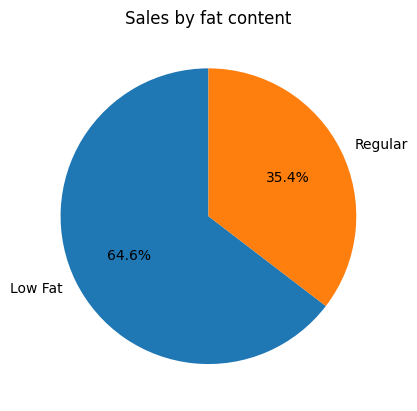

In [41]:
sales_by_fat=df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90)
plt.title('Sales by fat content')
plt.show()

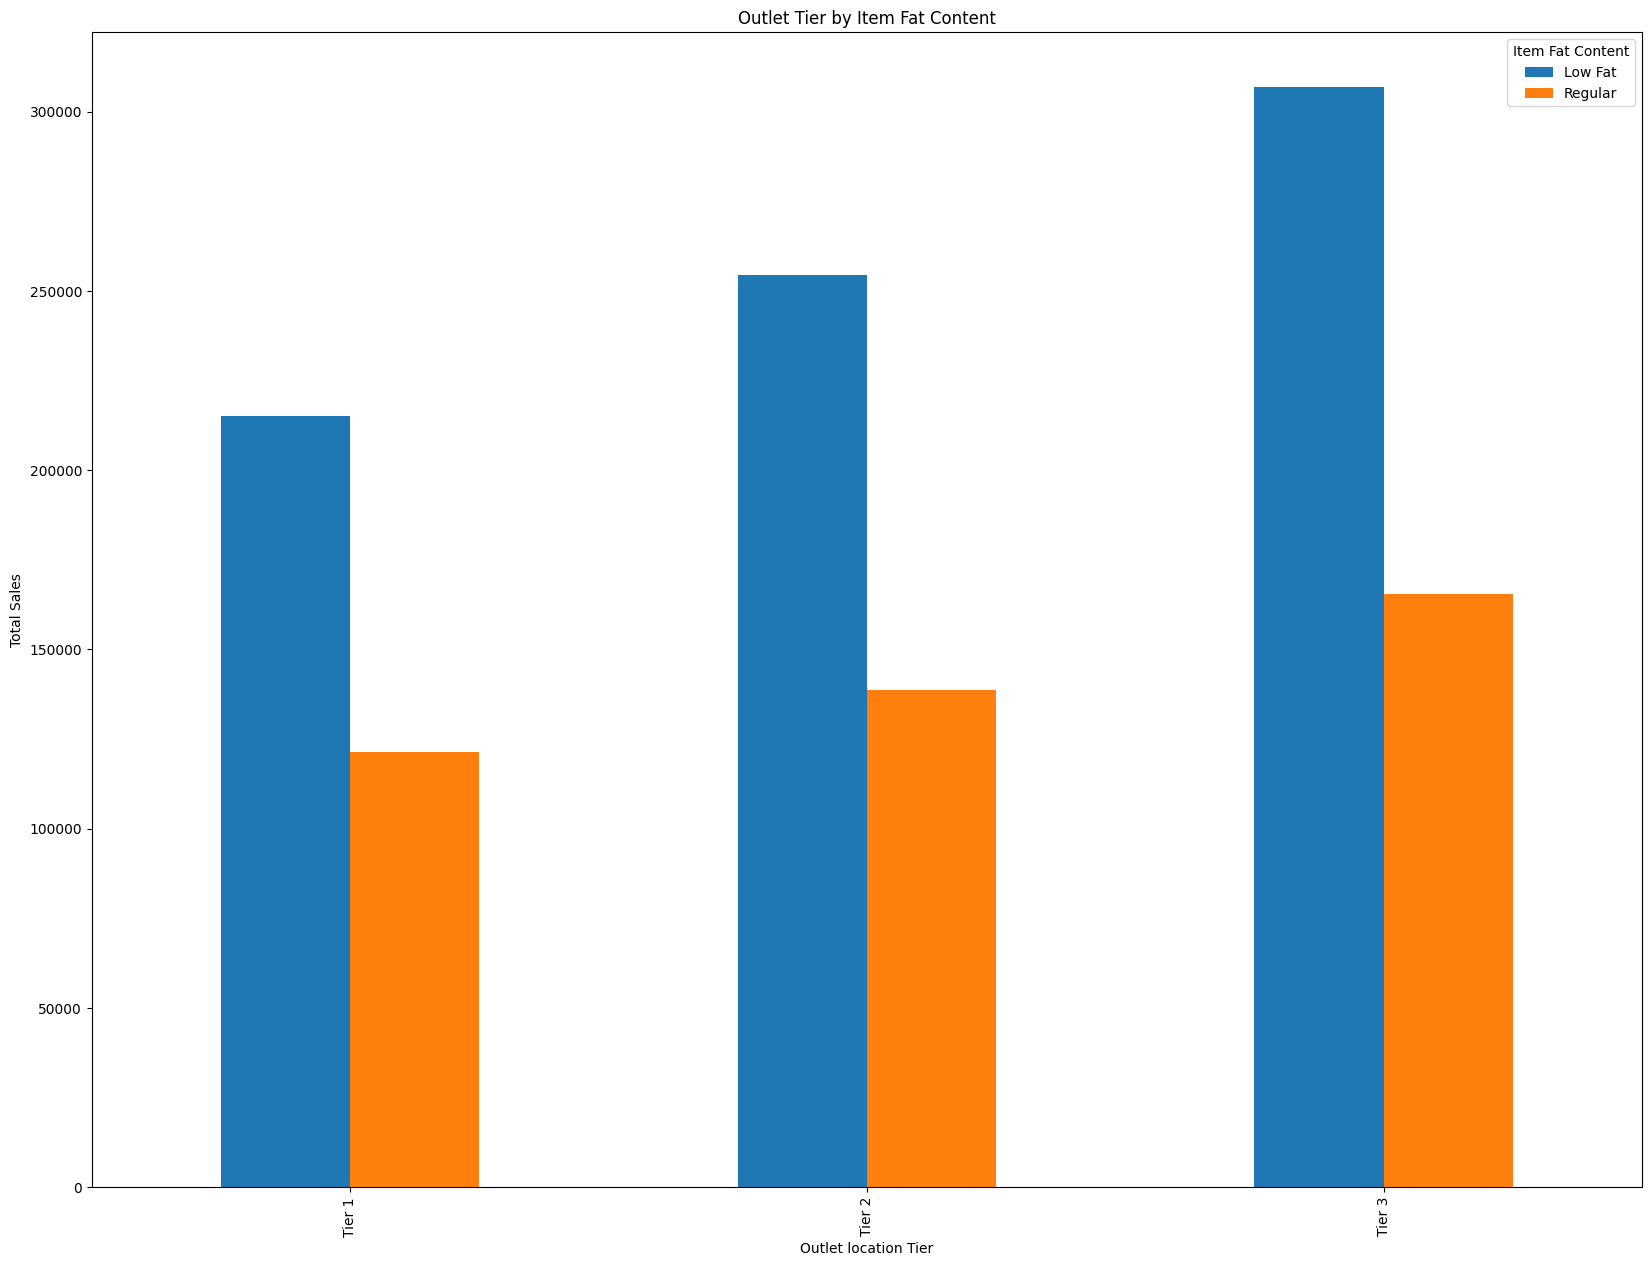

In [45]:
#Fat content of outlet for total sales
grouped=df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
ax=grouped.plot(kind='bar',figsize=(20,15),title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.show()